In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


OUTLIER HANDLES BY IQR TECHNIQUE - BOXPLOT ( TRIMMING & CAPPING )

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19884\1535942378.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19884\1535942378.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


<module 'matplotlib.pyplot' from 'c:\\Users\\vinay kumar\\OneDrive\\Documents\\vinay\\ML learning\\myenv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

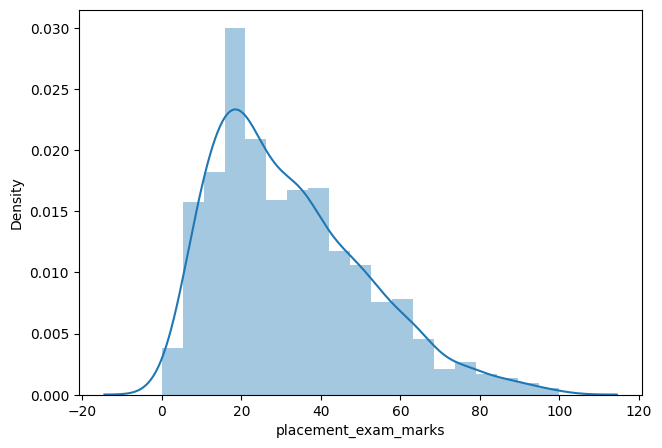

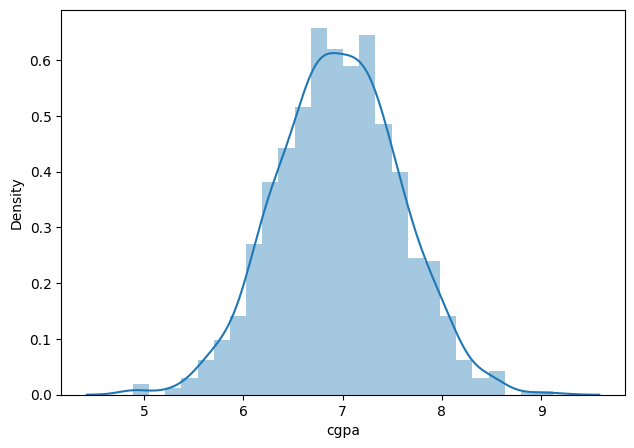

In [7]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['placement_exam_marks'])

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt

In [10]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

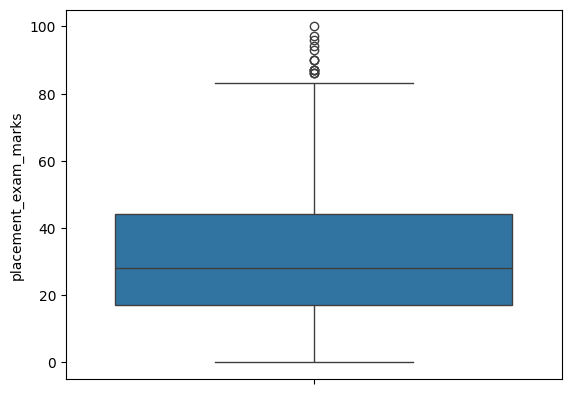

In [11]:
sns.boxplot(df['placement_exam_marks'])

finding the IQR 

In [13]:
precentlie25 = df['placement_exam_marks'].quantile(0.25)
precentlie75 = df['placement_exam_marks'].quantile(0.75)
iqr = precentlie75 - precentlie25

In [14]:
iqr

np.float64(27.0)

formula for IQR limits 


In [16]:
upper_limit = precentlie75 + (1.5 * iqr)
lower_limit = precentlie25 - (1.5 * iqr)

In [18]:
upper_limit , lower_limit

(np.float64(84.5), np.float64(-23.5))

In [28]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [25]:
df[df['placement_exam_marks'] > upper_limit].count()

cgpa                    15
placement_exam_marks    15
placed                  15
dtype: int64

In [31]:
df[df['placement_exam_marks'] < lower_limit].count()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

TRIMMING


In [33]:
new_df = df[df['placement_exam_marks']<upper_limit]

In [35]:
new_df.shape

(985, 3)

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19884\2754914695.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


<Axes: ylabel='placement_exam_marks'>

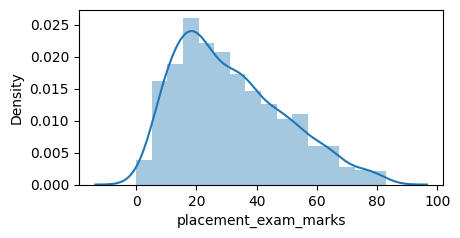

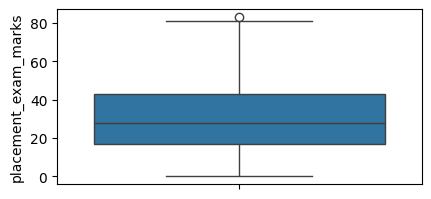

In [49]:
plt.figure(figsize=(16,5))
plt.subplot(2,3,2) 
sns.distplot(new_df['placement_exam_marks'])

plt.figure(figsize=(16,5))
plt.subplot(2,3,5) 
sns.boxplot(new_df['placement_exam_marks'])

CAPPING

In [51]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19884\3931319441.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_19884\3931319441.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_ma

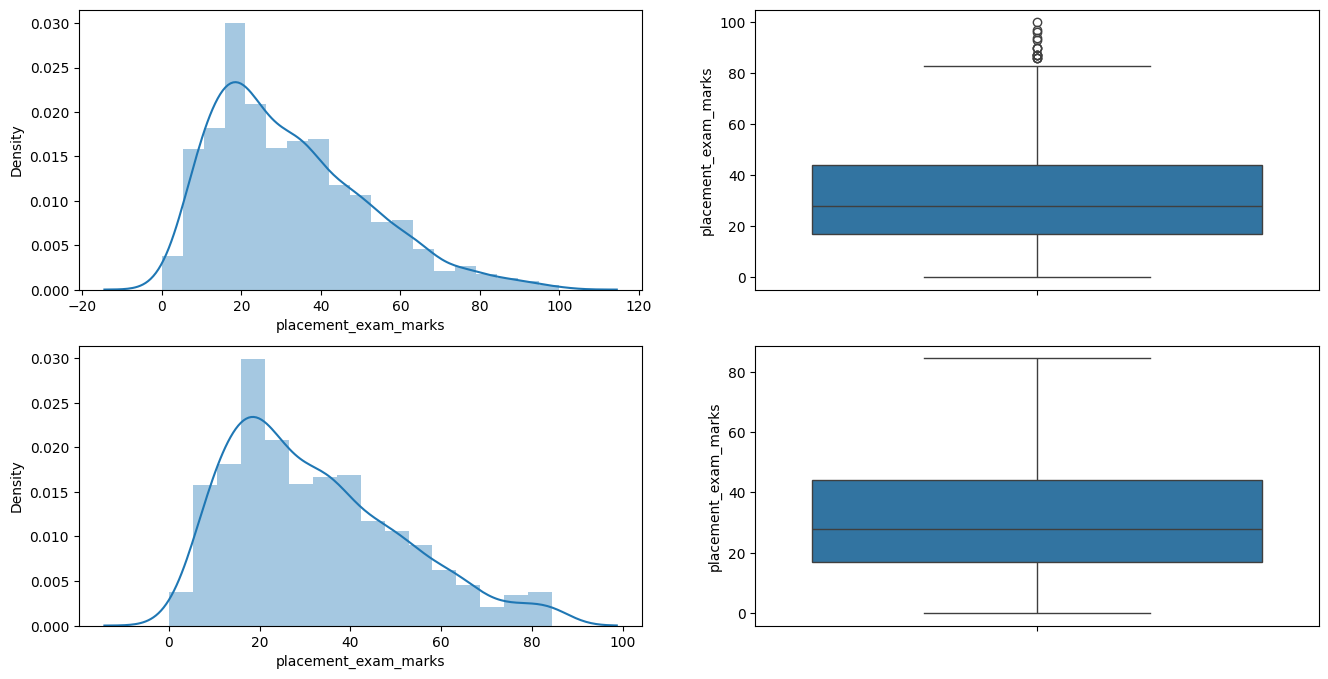

In [52]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()


ALL DONE
